# EDA — FICO HELOC

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
from scipy import stats

from pipeline import get_dataset, train_test_split, build_phi
from pipeline import train, score as model_score, predict, accuracy
from pipeline import fit_mice, get_imputation_params, get_mice_draws, compute_mu_sigma, calibrate_rho
from pipeline.data_fico import CSV_PATH, _HF_COLS, _TARGET_COL, _MISSING_SPECIAL, FEATURE_NAMES

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

## Load data

In [2]:
cfg = get_dataset('fico')
X, Xi, y, Phi, feature_names, col_means, col_stds = cfg.load()
train_idx, test_idx = train_test_split(len(y))

# also load raw CSV for summary stats in original scale
df_raw = pd.read_csv(CSV_PATH)
df_raw = df_raw[df_raw['nr_total_trades'] != -9].reset_index(drop=True)
X_raw = df_raw[_HF_COLS].values.astype(float)
# replace special values with NaN in raw view
for j in range(X_raw.shape[1]):
    mask = np.isin(X_raw[:, j], list(_MISSING_SPECIAL))
    X_raw[mask, j] = np.nan
y_raw = np.where(df_raw[_TARGET_COL].values == 1, -1, 1)

print(f'samples   : {len(y)}')
print(f'features  : {len(feature_names)}')
print(f'bad       : {(y==-1).sum()}  ({100*(y==-1).mean():.1f}%)')
print(f'good      : {(y==1).sum()}  ({100*(y==1).mean():.1f}%)')
print(f'train/test: {len(train_idx)} / {len(test_idx)}')

n=9871  d=23  good=4735  bad=5136
  ExternalRiskEstimate                        10 missing (0.1%)
  MSinceOldestTradeOpen                      239 missing (2.4%)
  MSinceMostRecentDelq                      4840 missing (49.0%)
  MSinceMostRecentInqexcl7days              2331 missing (23.6%)
  NetFractionRevolvingBurden                 186 missing (1.9%)
  NetFractionInstallBurden                  3419 missing (34.6%)
  NumRevolvingTradesWBalance                 156 missing (1.6%)
  NumInstallTradesWBalance                   861 missing (8.7%)
  NumBank2NatlTradesWHighUtilization         583 missing (5.9%)
  PercentTradesWBalance                       18 missing (0.2%)
samples   : 9871
features  : 23
bad       : 5136  (52.0%)
good      : 4735  (48.0%)
train/test: 7897 / 1974


## 1. Missingness per feature

In [3]:
miss_counts = Xi.sum(axis=0)
miss_pcts   = 100 * Xi.mean(axis=0)
miss_cols   = [j for j in range(len(feature_names)) if miss_pcts[j] > 0]

df_miss = pd.DataFrame({
    'n_missing': miss_counts,
    'pct_missing': miss_pcts.round(2),
}, index=feature_names)
df_miss

,n_missing,pct_missing
ExternalRiskEstimate,10,0.1000
MSinceOldestTradeOpen,239,2.4200
MSinceMostRecentTradeOpen,0,0.0000
AverageMInFile,0,0.0000
NumSatisfactoryTrades,0,0.0000
NumTrades60Ever2DerogPubRec,0,0.0000
NumTrades90Ever2DerogPubRec,0,0.0000
PercentTradesNeverDelq,0,0.0000
MSinceMostRecentDelq,4840,49.0300
MaxDelq2PublicRecLast12M,0,0.0000


In [4]:
total_cells   = Xi.shape[0] * Xi.shape[1]
missing_cells = Xi.sum()
rows_any      = (Xi.sum(axis=1) > 0).sum()
print(f'Overall missingness : {missing_cells}/{total_cells} = {100*missing_cells/total_cells:.1f}%')
print(f'Rows with >= 1 miss : {rows_any}/{len(y)} = {100*rows_any/len(y):.1f}%')
print(f'Features with miss  : {len(miss_cols)}/{len(feature_names)}')

Overall missingness : 12643/227033 = 5.6%
Rows with >= 1 miss : 7369/9871 = 74.7%
Features with miss  : 10/23


## 2. Missingness co-occurrence & pattern counts

In [5]:
miss_names = [feature_names[j] for j in miss_cols]

# co-occurrence table
cooccur = Xi[:, miss_cols].T @ Xi[:, miss_cols]
np.fill_diagonal(cooccur, 0)
print('Co-occurrence of missingness (off-diagonal = both missing):')
pd.DataFrame(cooccur, index=miss_names, columns=miss_names)

Co-occurrence of missingness (off-diagonal = both missing):


,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentDelq,MSinceMostRecentInqexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
ExternalRiskEstimate,0,0,6,2,7,7,7,7,7,7
MSinceOldestTradeOpen,0,0,124,128,5,90,4,24,12,0
MSinceMostRecentDelq,6,124,0,1192,103,1850,89,509,264,11
MSinceMostRecentInqexcl7days,2,128,1192,0,51,879,47,237,138,6
NetFractionRevolvingBurden,7,5,103,51,0,93,156,24,180,18
NetFractionInstallBurden,7,90,1850,879,93,0,78,861,240,18
NumRevolvingTradesWBalance,7,4,89,47,156,78,0,19,156,18
NumInstallTradesWBalance,7,24,509,237,24,861,19,0,74,18
NumBank2NatlTradesWHighUtilization,7,12,264,138,180,240,156,74,0,18
PercentTradesWBalance,7,0,11,6,18,18,18,18,18,0


In [6]:
# how many features are missing per person
k_missing = Xi.sum(axis=1)
print('# missing features per person:')
counts = {k: int((k_missing == k).sum()) for k in range(int(k_missing.max()) + 1)}
df_k = pd.DataFrame(list(counts.items()), columns=['k_missing', 'n_persons'])
df_k['pct'] = (df_k['n_persons'] / len(y) * 100).round(1)
display(df_k)
print(f'persons with >= 1 missing: {(k_missing > 0).sum()}  ({100*(k_missing > 0).mean():.1f}%)')

# missing features per person:


,k_missing,n_persons,pct
0,0,2502,25.3000
1,1,3863,39.1000
2,2,2241,22.7000
3,3,906,9.2000
4,4,271,2.7000
5,5,59,0.6000
6,6,12,0.1000
7,7,9,0.1000
8,8,6,0.1000
9,9,2,0.0000


persons with >= 1 missing: 7369  (74.7%)


## 3. Summary statistics & t-tests by class

In [7]:
rows = []
for j, name in enumerate(feature_names):
    obs  = ~np.isnan(X_raw[:, j])
    all_ = X_raw[obs, j]
    a    = X_raw[obs & (y_raw ==  1), j]   # good
    b    = X_raw[obs & (y_raw == -1), j]    # bad
    _, p = stats.ttest_ind(a, b)
    rows.append({
        'feature'    : name,
        'mean_all'   : round(all_.mean(), 2),
        'std_all'    : round(all_.std(),  2),
        'min'        : round(all_.min(),  2),
        'max'        : round(all_.max(),  2),
        'skew'       : round(stats.skew(all_), 2),
        'mean_good'  : round(a.mean(), 2),
        'mean_bad'   : round(b.mean(), 2),
        'diff'       : round(a.mean() - b.mean(), 2),
        'p_value'    : round(p, 4),
    })

pd.DataFrame(rows).set_index('feature')

,mean_all,std_all,min,max,skew,mean_good,mean_bad,diff,p_value
feature,,,,,,,,,
ExternalRiskEstimate,72.0600,9.8700,33.0000,94.0000,0.0000,76.7900,67.6900,9.1000,0.0000
MSinceOldestTradeOpen,200.7700,97.9400,2.0000,803.0000,0.7100,222.7900,180.4300,42.3600,0.0000
MSinceMostRecentTradeOpen,9.5900,12.9600,0.0000,383.0000,7.0900,10.2100,9.0100,1.2000,0.0000
AverageMInFile,78.7800,34.0600,4.0000,383.0000,0.9200,87.4300,70.8000,16.6300,0.0000
NumSatisfactoryTrades,21.1200,11.3200,0.0000,79.0000,0.8000,22.7900,19.5900,3.2000,0.0000
NumTrades60Ever2DerogPubRec,0.5800,1.2400,0.0000,19.0000,4.1700,0.3600,0.7800,-0.4200,0.0000
NumTrades90Ever2DerogPubRec,0.3800,0.9900,0.0000,19.0000,5.4500,0.2400,0.5200,-0.2800,0.0000
PercentTradesNeverDelq,92.3600,11.7700,0.0000,100.0000,-2.4300,95.5200,89.4500,6.0600,0.0000
MSinceMostRecentDelq,21.8800,20.8100,0.0000,83.0000,1.0700,27.0500,18.8500,8.2000,0.0000


## 4. Correlation matrix (fully-observed rows, standardized)

Fully-observed rows: 2502 / 9871


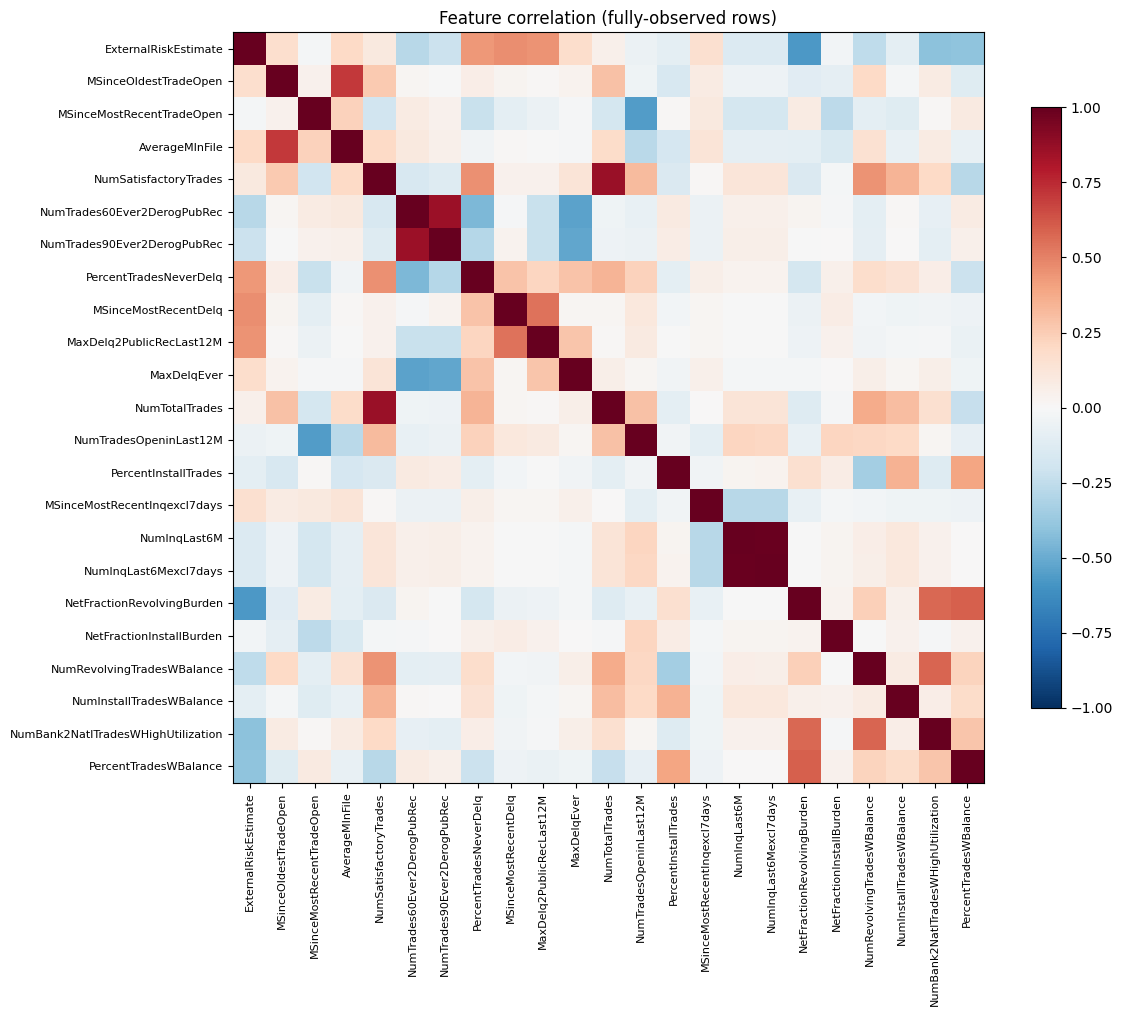

In [8]:
import matplotlib.pyplot as plt

obs_mask = Xi.sum(axis=1) == 0
print(f'Fully-observed rows: {obs_mask.sum()} / {len(y)}')
corr = np.corrcoef(X[obs_mask].T)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_names)))
ax.set_yticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=90, fontsize=8)
ax.set_yticklabels(feature_names, fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Feature correlation (fully-observed rows)')
plt.tight_layout()
plt.show()

## 5. Missingness vs outcome (chi-square)

In [9]:
rows = []
for j in miss_cols:
    name = feature_names[j]
    m_bad  = int(((Xi[:, j] == 1) & (y == -1)).sum())
    m_good = int(((Xi[:, j] == 1) & (y ==  1)).sum())
    o_bad  = int(((Xi[:, j] == 0) & (y == -1)).sum())
    o_good = int(((Xi[:, j] == 0) & (y ==  1)).sum())
    chi2, p, _, _ = stats.chi2_contingency(np.array([[m_bad, m_good], [o_bad, o_good]]))
    rows.append({
        'feature': name,
        'miss_bad': m_bad, 'miss_good': m_good,
        'obs_bad': o_bad, 'obs_good': o_good,
        'chi2': round(chi2, 2), 'p_value': round(p, 4),
    })

print('Is missingness associated with outcome?')
pd.DataFrame(rows).set_index('feature')

Is missingness associated with outcome?


,miss_bad,miss_good,obs_bad,obs_good,chi2,p_value
feature,,,,,,
ExternalRiskEstimate,8,2,5128,4733,2.1200,0.1458
MSinceOldestTradeOpen,129,110,5007,4625,0.3000,0.5869
MSinceMostRecentDelq,1964,2876,3172,1859,498.1500,0.0000
MSinceMostRecentInqexcl7days,1219,1112,3917,3623,0.0700,0.7886
NetFractionRevolvingBurden,149,37,4987,4698,58.7300,0.0000
NetFractionInstallBurden,1605,1814,3531,2921,53.9400,0.0000
NumRevolvingTradesWBalance,128,28,5008,4707,56.0200,0.0000
NumInstallTradesWBalance,398,463,4738,4272,12.4900,0.0004
NumBank2NatlTradesWHighUtilization,423,160,4713,4575,103.7000,0.0000


## 6. MICE imputation

In [10]:
import warnings

N_IMPUTATIONS = 10

mice_imputer = fit_mice(X[train_idx], Xi[train_idx], max_iter=10, seed=42)

# generate N_IMPUTATIONS complete datasets and measure stability
X_nan = X[train_idx].copy().astype(float)
X_nan[Xi[train_idx] == 1] = np.nan

imputations = []
for k in range(N_IMPUTATIONS):
    mice_imputer.random_state_ = np.random.RandomState(k)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        X_imp = mice_imputer.transform(X_nan)
    imputations.append(X_imp)

imputations = np.stack(imputations)  # (N_IMPUTATIONS, n_train, d)
print(f'Imputations shape: {imputations.shape}')

Imputations shape: (10, 7897, 23)


In [11]:
# RMSE across imputations (only on cells that were missing)
Xi_train = Xi[train_idx]
rmse_per_run = []
# use mean of all imputations as pseudo-ground-truth for measuring spread
imp_mean = imputations.mean(axis=0)

for k in range(N_IMPUTATIONS):
    diff = (imputations[k] - imp_mean)[Xi_train == 1]
    rmse_per_run.append(np.sqrt((diff ** 2).mean()))

print(f'Imputation RMSE (spread across {N_IMPUTATIONS} runs): {np.mean(rmse_per_run):.3f} +/- {np.std(rmse_per_run):.3f}')

# per-feature STD of imputed values (only missing cells)
print(f'\nPer-feature mean STD of imputed values (missing cells only):')
rows = []
for j in miss_cols:
    name = feature_names[j]
    mask = Xi_train[:, j] == 1
    if mask.sum() == 0:
        continue
    vals = imputations[:, mask, j]  # (N_IMPUTATIONS, n_missing_j)
    mean_std = vals.std(axis=0).mean()

    # unstandardize the STD for interpretability
    mean_std_raw = mean_std * col_stds[j]
    rows.append({'feature': name, 'n_missing': int(mask.sum()), 'mean_STD': round(mean_std_raw, 3)})

df_mice = pd.DataFrame(rows).set_index('feature').sort_values('n_missing', ascending=False)
df_mice

Imputation RMSE (spread across 10 runs): 0.796 +/- 0.004

Per-feature mean STD of imputed values (missing cells only):


,n_missing,mean_STD
feature,,
MSinceMostRecentDelq,3876,14.2660
NetFractionInstallBurden,2718,21.9920
MSinceMostRecentInqexcl7days,1867,4.1220
NumInstallTradesWBalance,678,1.1970
NumBank2NatlTradesWHighUtilization,460,0.9560
MSinceOldestTradeOpen,199,60.8900
NetFractionRevolvingBurden,153,16.5100
NumRevolvingTradesWBalance,130,1.7600
PercentTradesWBalance,14,17.6820


## 7. Downstream model (logistic regression with CV-tuned C)

In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression

# 3-fold stratified CV to select best C
C_grid = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

results = {C: [] for C in C_grid}
for fold_i, (tr, va) in enumerate(cv.split(Phi, y)):
    for C in C_grid:
        model = LogisticRegression(C=C, max_iter=1000, solver='lbfgs')
        model.fit(Phi[tr], y[tr])
        acc = (model.predict(Phi[va]) == y[va]).mean()
        results[C].append(acc)

print(f'{"C":>8}   {"mean_acc":>8}   {"std":>8}')
print('-' * 30)
best_C, best_acc = None, 0.0
for C in C_grid:
    m = np.mean(results[C])
    s = np.std(results[C])
    tag = ''
    if m > best_acc:
        best_acc = m
        best_C = C
        tag = ' <--'
    print(f'{C:>8.3f}   {m:>8.3f}   {s:>8.3f}{tag}')

print(f'\nBest C = {best_C}  (accuracy = {best_acc:.3f})')

       C   mean_acc        std
------------------------------
   0.001      0.732      0.003 <--
   0.010      0.733      0.001 <--
   0.100      0.732      0.001
   1.000      0.731      0.001
  10.000      0.731      0.001
 100.000      0.731      0.001

Best C = 0.01  (accuracy = 0.733)


/Users/neilgandhi/.pyenv/versions/3.12.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/neilgandhi/.pyenv/versions/3.12.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/neilgandhi/.pyenv/versions/3.12.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/neilgandhi/.pyenv/versions/3.12.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/neilgandhi/.pyenv/versions/3.12.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encou

## 8. Model overview (using best C)

In [13]:
theta_hat, _ = train(Phi[train_idx], y[train_idx], C=best_C)
test_scores  = model_score(Phi[test_idx], theta_hat)
train_acc    = (predict(Phi[train_idx], theta_hat) == y[train_idx]).mean()
test_acc     = (predict(Phi[test_idx],  theta_hat) == y[test_idx]).mean()

denied_test         = [i for i in test_idx if predict(Phi[[i]], theta_hat)[0] == -1]
denied_with_missing = [i for i in denied_test if Xi[i].sum() > 0]

print(f'phi shape                    : {Phi.shape}  (n x 2d)')
print(f'theta shape                  : {theta_hat.shape}  (2d+1 with bias)')
print(f'best C                       : {best_C}')
print(f'train acc                    : {train_acc:.3f}')
print(f'test acc                     : {test_acc:.3f}')
print(f'denied (test)                : {len(denied_test)}')
print(f'denied (test) with missing   : {len(denied_with_missing)}')
print()
print('Test score distribution:')
for label, name in [(-1, 'bad (denied)'), (1, 'good (approved)')]:
    s = test_scores[y[test_idx] == label]
    print(f'  {name:<20}  mean={s.mean():+.3f}  std={s.std():.3f}  '
          f'min={s.min():+.3f}  max={s.max():+.3f}')

phi shape                    : (9871, 46)  (n x 2d)
theta shape                  : (47,)  (2d+1 with bias)
best C                       : 0.01
train acc                    : 0.734
test acc                     : 0.728
denied (test)                : 1034
denied (test) with missing   : 690

Test score distribution:
  bad (denied)          mean=-0.686  std=1.074  min=-4.213  max=+2.550
  good (approved)       mean=+0.611  std=1.081  min=-4.874  max=+3.074


## 9. Learned weights $\hat\theta$

In [14]:
d    = len(feature_names)
w_x  = theta_hat[:d]
w_xi = theta_hat[d:2*d]
bias = theta_hat[-1]

print(f'bias: {bias:.4f}')
df_w = pd.DataFrame({
    'w_x'    : w_x.round(4),
    'w_xi'   : w_xi.round(4),
    '|w_x|'  : np.abs(w_x).round(4),
}, index=feature_names)
df_w.sort_values('|w_x|', ascending=False)

bias: -0.1591


,w_x,w_xi,|w_x|
ExternalRiskEstimate,0.4275,-0.0010,0.4275
NumSatisfactoryTrades,0.2942,0.0000,0.2942
AverageMInFile,0.2896,0.0000,0.2896
NetFractionRevolvingBurden,-0.2714,0.0103,0.2714
MSinceMostRecentInqexcl7days,0.2042,-0.0673,0.2042
NumBank2NatlTradesWHighUtilization,-0.1773,-0.1535,0.1773
PercentTradesNeverDelq,0.1689,0.0000,0.1689
NumInqLast6M,-0.1607,0.0000,0.1607
MSinceMostRecentDelq,0.1482,0.1709,0.1482
NumRevolvingTradesWBalance,-0.1443,0.0239,0.1443


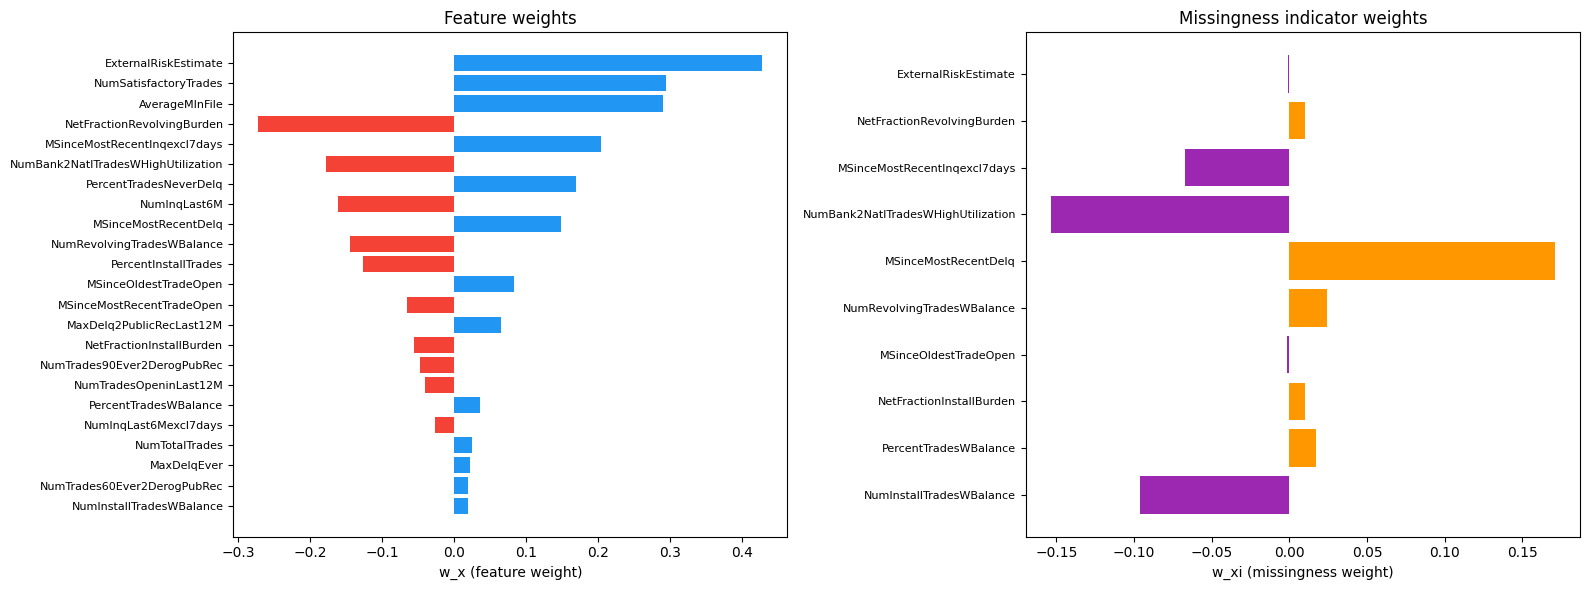

In [15]:
# visualize weights
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order = np.argsort(np.abs(w_x))[::-1]
names_sorted = [feature_names[i] for i in order]

axes[0].barh(range(d), w_x[order], color=['#2196F3' if v >= 0 else '#F44336' for v in w_x[order]])
axes[0].set_yticks(range(d))
axes[0].set_yticklabels(names_sorted, fontsize=8)
axes[0].set_xlabel('w_x (feature weight)')
axes[0].set_title('Feature weights')
axes[0].invert_yaxis()

# missingness weights (only for features that can be missing)
miss_order = [j for j in order if j in miss_cols]
miss_names_sorted = [feature_names[j] for j in miss_order]
miss_w = [w_xi[j] for j in miss_order]

axes[1].barh(range(len(miss_order)), miss_w,
             color=['#FF9800' if v >= 0 else '#9C27B0' for v in miss_w])
axes[1].set_yticks(range(len(miss_order)))
axes[1].set_yticklabels(miss_names_sorted, fontsize=8)
axes[1].set_xlabel('w_xi (missingness weight)')
axes[1].set_title('Missingness indicator weights')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()